In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_csv("/content/Delivery_Logistics.csv")

In [7]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [8]:
df.shape

(25000, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), object(10)


In [10]:
df.describe()

,delivery_id,distance_km,package_weight_kg,delivery_rating,delivery_cost
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,3.666000,864.944579
std,7212.732314,86.409745,14.368663,1.149964,435.712593
min,250.990000,3.600000,0.670000,1.000000,95.667400
25%,6250.750000,75.900000,12.680000,3.000000,490.800000
50%,12500.500000,151.000000,25.145000,4.000000,867.535000
75%,18750.250000,224.900000,37.660000,5.000000,1237.910000
max,24750.010000,297.100000,49.520000,5.000000,1632.720600


In [11]:
df.isnull().sum()

,0
delivery_id,0
delivery_partner,0
package_type,0
vehicle_type,0
delivery_mode,0
region,0
weather_condition,0
distance_km,0
package_weight_kg,0
delivery_time_hours,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.nunique()

,0
delivery_id,24502
delivery_partner,9
package_type,9
vehicle_type,6
delivery_mode,4
region,5
weather_condition,6
distance_km,2935
package_weight_kg,4853
delivery_time_hours,20


In [14]:
df["delivery_time_hours"].head(10)

,delivery_time_hours
0,1970-01-01 00:00:00.000000008
1,1970-01-01 00:00:00.000000002
2,1970-01-01 00:00:00.000000010
3,1970-01-01 00:00:00.000000006
4,1970-01-01 00:00:00.000000009
5,1970-01-01 00:00:00.000000004
6,1970-01-01 00:00:00.000000006
7,1970-01-01 00:00:00.000000004
8,1970-01-01 00:00:00.000000005
9,1970-01-01 00:00:00.000000003


In [15]:
df["expected_time_hours"].head(10)

,expected_time_hours
0,1970-01-01 00:00:00.000000008
1,1970-01-01 00:00:00.000000003
2,1970-01-01 00:00:00.000000016
3,1970-01-01 00:00:00.000000008
4,1970-01-01 00:00:00.000000016
5,1970-01-01 00:00:00.000000002
6,1970-01-01 00:00:00.000000008
7,1970-01-01 00:00:00.000000008
8,1970-01-01 00:00:00.000000008
9,1970-01-01 00:00:00.000000008


In [16]:
df["delivery_time_hours"].dtype

dtype('O')

In [17]:
df["expected_time_hours"].dtype

dtype('O')

In [19]:
df["delivery_time_hours"] = (
    pd.to_datetime(df["delivery_time_hours"])
    .dt.nanosecond
)

df["expected_time_hours"] = (
    pd.to_datetime(df["expected_time_hours"])
    .dt.nanosecond
)


In [20]:
df[["delivery_time_hours","expected_time_hours"]].head(10)

,delivery_time_hours,expected_time_hours
0,8,8
1,2,3
2,10,16
3,6,8
4,9,16
5,4,2
6,6,8
7,4,8
8,5,8
9,3,8


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  int32  
 10  expected_time_hours  25000 non-null  int32  
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int32(2), int64(1), o

In [22]:
df.describe()

,delivery_id,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,6.248040,13.107680,3.666000,864.944579
std,7212.732314,86.409745,14.368663,3.140935,7.559024,1.149964,435.712593
min,250.990000,3.600000,0.670000,0.000000,2.000000,1.000000,95.667400
25%,6250.750000,75.900000,12.680000,4.000000,8.000000,3.000000,490.800000
50%,12500.500000,151.000000,25.145000,6.000000,8.000000,4.000000,867.535000
75%,18750.250000,224.900000,37.660000,8.000000,16.000000,5.000000,1237.910000
max,24750.010000,297.100000,49.520000,19.000000,24.000000,5.000000,1632.720600


In [23]:
print("Total Deliveries:", len(df))

Total Deliveries: 25000


In [24]:
df["delivery_status"].value_counts()

,count
delivery_status,
delivered,18331
delayed,5341
failed,1328


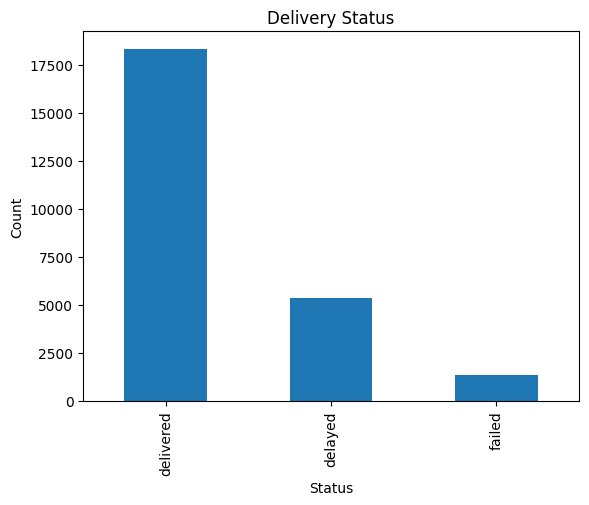

In [25]:
import matplotlib.pyplot as plt

df["delivery_status"].value_counts().plot(kind="bar")

plt.title("Delivery Status")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

In [26]:
df["delivery_partner"].value_counts()

,count
delivery_partner,
xpressbees,2826
fedex,2818
dhl,2802
ekart,2801
blue dart,2798
delhivery,2786
shadowfax,2736
ecom express,2722
amazon logistics,2711


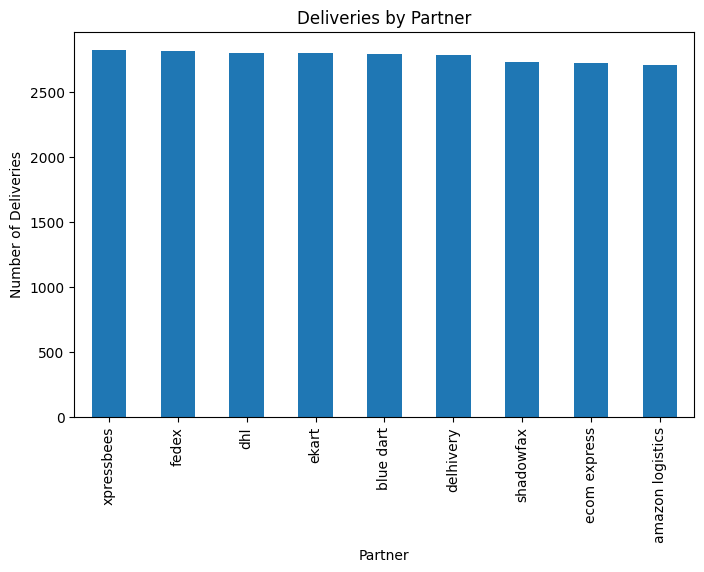

In [27]:
df["delivery_partner"].value_counts().plot(kind="bar", figsize=(8,5))

plt.title("Deliveries by Partner")
plt.xlabel("Partner")
plt.ylabel("Number of Deliveries")

plt.show()

In [28]:
df["vehicle_type"].value_counts()

,count
vehicle_type,
ev bike,4218
van,4187
scooter,4174
bike,4160
truck,4145
ev van,4116


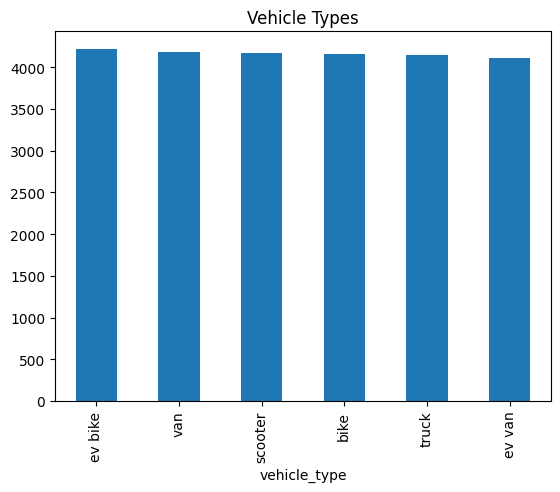

In [29]:
df["vehicle_type"].value_counts().plot(kind="bar")

plt.title("Vehicle Types")

plt.show()

In [30]:
df["weather_condition"].value_counts()

,count
weather_condition,
foggy,4219
stormy,4198
rainy,4171
cold,4158
hot,4130
clear,4124


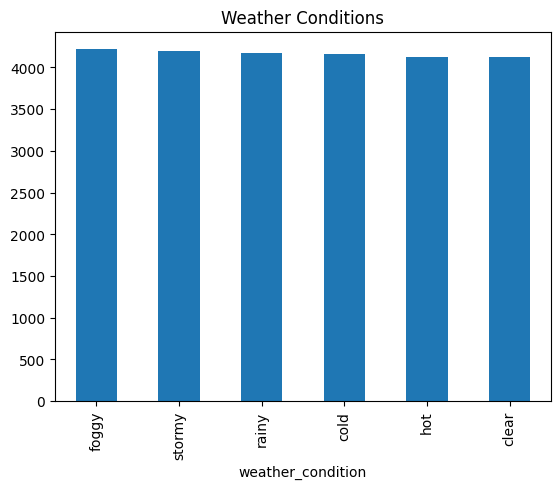

In [31]:
df["weather_condition"].value_counts().plot(kind="bar")

plt.title("Weather Conditions")

plt.show()

In [32]:
df["delivery_mode"].value_counts()

,count
delivery_mode,
two day,6302
same day,6279
express,6233
standard,6186


In [33]:
df["region"].value_counts()

,count
region,
west,5095
central,5060
south,4977
north,4949
east,4919


In [34]:
df["package_type"].value_counts()

,count
package_type,
fragile items,2848
pharmacy,2810
documents,2805
automobile parts,2795
electronics,2792
clothing,2767
furniture,2746
cosmetics,2744
groceries,2693


In [35]:
print(df["delivery_cost"].mean())

864.9445787999999


In [36]:
print(df["delivery_time_hours"].mean())

6.24804


In [37]:
print(df["delivery_rating"].mean())

3.666


In [38]:
# Total deliveries
print("Total Deliveries:", len(df))

# Delivery status
print("\nDelivery Status:")
print(df["delivery_status"].value_counts())

# Delivery partners
print("\nDelivery Partners:")
print(df["delivery_partner"].value_counts())

# Vehicle types
print("\nVehicle Types:")
print(df["vehicle_type"].value_counts())

# Weather conditions
print("\nWeather Conditions:")
print(df["weather_condition"].value_counts())

# Delivery modes
print("\nDelivery Modes:")
print(df["delivery_mode"].value_counts())

# Regions
print("\nRegions:")
print(df["region"].value_counts())

# Package types
print("\nPackage Types:")
print(df["package_type"].value_counts())

# Average values
print("\nAverage Delivery Cost:", round(df["delivery_cost"].mean(),2))
print("Average Delivery Time:", round(df["delivery_time_hours"].mean(),2))
print("Average Rating:", round(df["delivery_rating"].mean(),2))

Total Deliveries: 25000

Delivery Status:
delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64

Delivery Partners:
delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64

Vehicle Types:
vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64

Weather Conditions:
weather_condition
foggy     4219
stormy    4198
rainy     4171
cold      4158
hot       4130
clear     4124
Name: count, dtype: int64

Delivery Modes:
delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64

Regions:
region
west       5095
central    5060
south      4977
north      4949
east       4919
Name: count, dtype: int64

Package Types:
p

In [39]:
df["delay_hours"] = df["delivery_time_hours"] - df["expected_time_hours"]

In [40]:
df["cost_per_km"] = df["delivery_cost"] / df["distance_km"]

In [41]:
import numpy as np

df["package_category"] = np.where(
    df["package_weight_kg"] > 20,
    "Heavy",
    "Light"
)

In [42]:
df["delivery_performance"] = np.where(
    df["delayed"] == "no",
    "On Time",
    "Delayed"
)

In [43]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost,delay_hours,cost_per_km,package_category,delivery_performance
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,8,8,no,delivered,3,1632.7206,0,5.497376,Heavy,On Time
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,2,3,no,delivered,5,640.1700,-1,7.144754,Heavy,On Time
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,10,16,no,delivered,4,1448.1700,-6,5.294954,Heavy,On Time
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,6,8,no,delivered,3,1486.5700,-2,5.511939,Light,On Time
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,9,16,no,delivered,4,1394.5600,-7,5.432645,Heavy,On Time


In [44]:
df["delivery_performance"].value_counts()

,count
delivery_performance,
On Time,18331
Delayed,6669


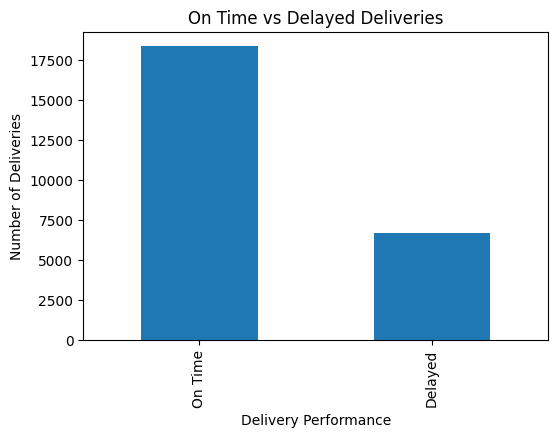

In [45]:
df["delivery_performance"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("On Time vs Delayed Deliveries")
plt.xlabel("Delivery Performance")
plt.ylabel("Number of Deliveries")

plt.show()

In [46]:
df["delivery_partner"].value_counts()

,count
delivery_partner,
xpressbees,2826
fedex,2818
dhl,2802
ekart,2801
blue dart,2798
delhivery,2786
shadowfax,2736
ecom express,2722
amazon logistics,2711


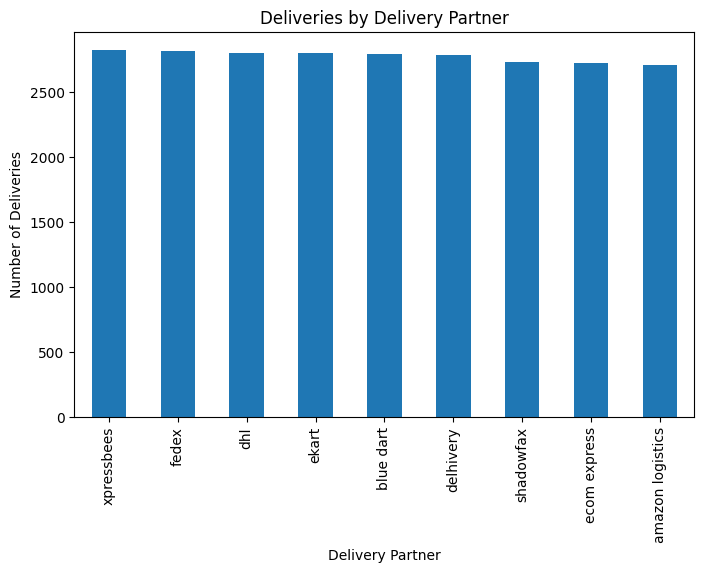

In [47]:
df["delivery_partner"].value_counts().plot(kind="bar", figsize=(8,5))

plt.title("Deliveries by Delivery Partner")
plt.xlabel("Delivery Partner")
plt.ylabel("Number of Deliveries")

plt.show()

In [48]:
df.groupby("delivery_partner")["delivery_cost"].mean().sort_values(ascending=False)

,delivery_cost
delivery_partner,
dhl,872.831125
ekart,869.966720
ecom express,868.772186
shadowfax,868.340156
xpressbees,868.165768
amazon logistics,868.150131
blue dart,863.021705
fedex,857.355640
delhivery,848.109810


In [49]:
df.groupby("vehicle_type")["delivery_cost"].mean().sort_values(ascending=False)

,delivery_cost
vehicle_type,
ev bike,869.235484
bike,868.917038
ev van,866.181463
truck,864.768182
scooter,862.914003
van,857.658050


In [50]:
df.groupby("weather_condition")["delivery_time_hours"].mean().sort_values(ascending=False)

,delivery_time_hours
weather_condition,
stormy,8.807527
rainy,7.804843
foggy,6.486608
hot,4.784504
clear,4.776431
cold,4.773449


In [51]:
partner_rating = (
    df.groupby("delivery_partner")["delivery_rating"]
      .mean()
      .sort_values(ascending=False)
)

print(partner_rating)

delivery_partner
fedex               3.698368
delhivery           3.687724
dhl                 3.685225
blue dart           3.677627
ecom express        3.674504
shadowfax           3.661550
ekart               3.655480
amazon logistics    3.644412
xpressbees          3.608988
Name: delivery_rating, dtype: float64


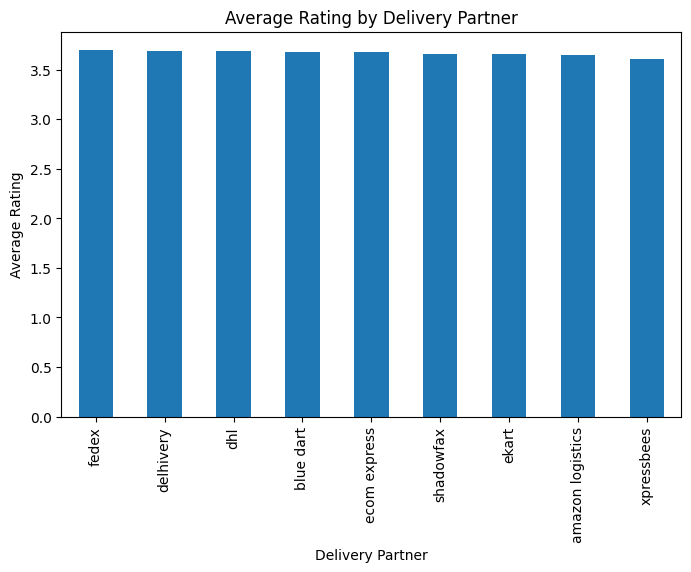

In [52]:
partner_rating.plot(kind="bar", figsize=(8,5))

plt.title("Average Rating by Delivery Partner")
plt.xlabel("Delivery Partner")
plt.ylabel("Average Rating")

plt.show()

In [53]:
region_cost = (
    df.groupby("region")["delivery_cost"]
      .mean()
      .sort_values(ascending=False)
)

print(region_cost)

region
west       874.211232
central    869.950989
east       861.455929
north      860.439223
south      858.296324
Name: delivery_cost, dtype: float64


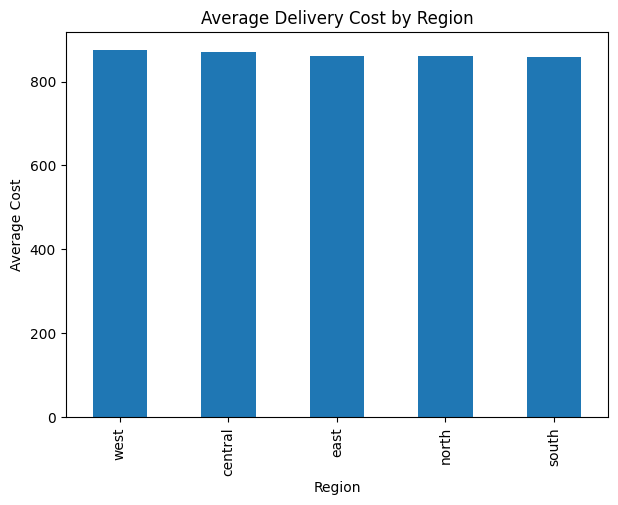

In [54]:
region_cost.plot(kind="bar", figsize=(7,5))

plt.title("Average Delivery Cost by Region")
plt.xlabel("Region")
plt.ylabel("Average Cost")

plt.show()

In [55]:
weather_time = (
    df.groupby("weather_condition")["delivery_time_hours"]
      .mean()
      .sort_values(ascending=False)
)

print(weather_time)

weather_condition
stormy    8.807527
rainy     7.804843
foggy     6.486608
hot       4.784504
clear     4.776431
cold      4.773449
Name: delivery_time_hours, dtype: float64


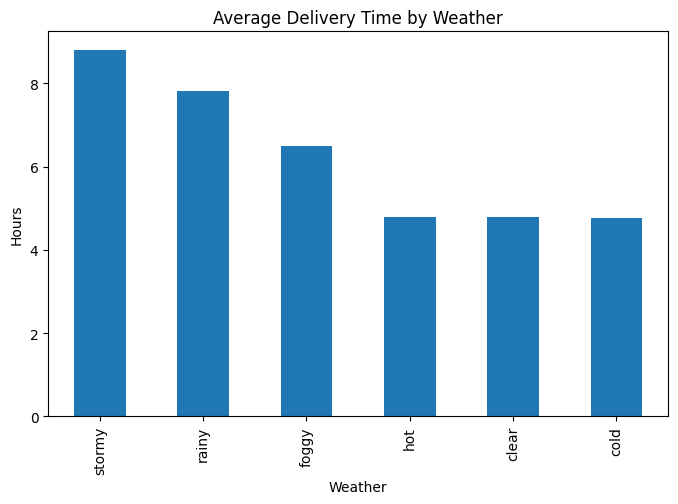

In [56]:
weather_time.plot(kind="bar", figsize=(8,5))

plt.title("Average Delivery Time by Weather")
plt.xlabel("Weather")
plt.ylabel("Hours")

plt.show()

In [57]:
vehicle_cost = (
    df.groupby("vehicle_type")["delivery_cost"]
      .mean()
      .sort_values(ascending=False)
)

print(vehicle_cost)

vehicle_type
ev bike    869.235484
bike       868.917038
ev van     866.181463
truck      864.768182
scooter    862.914003
van        857.658050
Name: delivery_cost, dtype: float64


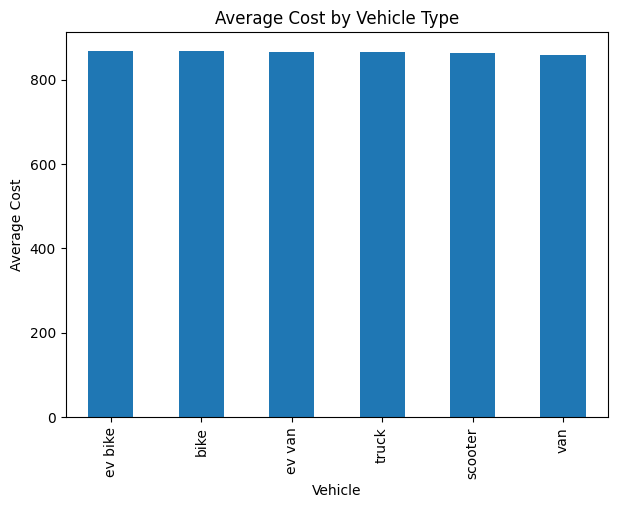

In [58]:
vehicle_cost.plot(kind="bar", figsize=(7,5))

plt.title("Average Cost by Vehicle Type")
plt.xlabel("Vehicle")
plt.ylabel("Average Cost")

plt.show()

In [59]:
package_cost = (
    df.groupby("package_type")["delivery_cost"]
      .mean()
      .sort_values(ascending=False)
)

print(package_cost)

package_type
clothing            879.421551
automobile parts    877.182380
pharmacy            873.003255
cosmetics           870.800874
furniture           866.719703
groceries           861.846692
electronics         857.739423
documents           850.833296
fragile items       847.455137
Name: delivery_cost, dtype: float64


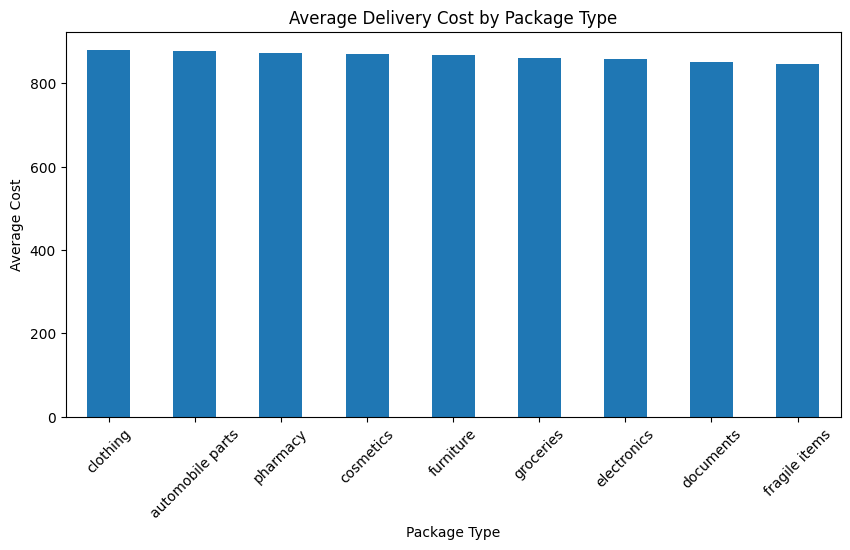

In [60]:
package_cost.plot(kind="bar", figsize=(10,5))

plt.title("Average Delivery Cost by Package Type")
plt.xlabel("Package Type")
plt.ylabel("Average Cost")

plt.xticks(rotation=45)

plt.show()

In [61]:
partner_delay = (
    df.groupby("delivery_partner")["delayed"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

print(partner_delay)

delivery_partner
xpressbees          28.273178
ekart               27.418779
shadowfax           27.302632
amazon logistics    27.222427
blue dart           26.947820
ecom express        26.634827
dhl                 26.338330
fedex               25.159688
delhivery           24.802584
Name: delayed, dtype: float64


In [62]:
weather_delay = (
    df.groupby("weather_condition")["delayed"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

print(weather_delay)

weather_condition
stormy    41.448309
rainy     37.353153
foggy     30.315241
clear     17.434530
hot       17.118644
cold      16.017316
Name: delayed, dtype: float64


In [63]:
delivery_mode_time = (
    df.groupby("delivery_mode")["delivery_time_hours"]
      .mean()
      .sort_values()
)

print(delivery_mode_time)

delivery_mode
express     6.230868
standard    6.237472
same day    6.244784
two day     6.278642
Name: delivery_time_hours, dtype: float64


In [64]:
package_category_cost = (
    df.groupby("package_category")["delivery_cost"]
      .mean()
)

print(package_category_cost)

package_category
Heavy    896.062882
Light    817.536832
Name: delivery_cost, dtype: float64


In [65]:
region_rating = (
    df.groupby("region")["delivery_rating"]
      .mean()
      .sort_values(ascending=False)
)

print(region_rating)

region
east       3.682252
north      3.679935
south      3.667671
central    3.660672
west       3.640432
Name: delivery_rating, dtype: float64


In [66]:
df.columns

Index(['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type',
       'delivery_mode', 'region', 'weather_condition', 'distance_km',
       'package_weight_kg', 'delivery_time_hours', 'expected_time_hours',
       'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost',
       'delay_hours', 'cost_per_km', 'package_category',
       'delivery_performance'],
      dtype='object')

In [67]:
df.to_csv("clean_supply_chain_data.csv", index=False)

In [68]:
from google.colab import files
files.download("clean_supply_chain_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>